# 📌 Understanding the problem, SGD for Linear Regression with Housing Dataset

# ✅ Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ✅ Load the Housing Dataset

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/Phionanamugga/teaching/refs/heads/main/datasets/housing.csv")

# ✅ Explore the dataset

In [7]:
print(df.head())
print(df.info())

   id     price  area  bedrooms  bathrooms  stories  stories.1  guestroom  \
0   0  13300000  7420         4          2        3          1          0   
1   1  12250000  8960         4          4        4          1          0   
2   2  12250000  9960         3          2        2          1          0   
3   3  12215000  7500         4          2        2          1          0   
4   4  11410000  7420         4          1        2          1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0               1.0  
1               1.0  
2               0.5  
3               1.0  
4               1.

# ✅ Select Features (X) and Target (y)
# Assuming 'MEDV' (Median Home Value) is the target variable

In [8]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values 

# ✅ Normalizing features and Splitting data into Training & Test Sets

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_test_scaled = scaler.transform(X_test)


# 📌 Add Bias Term (Column of Ones)

In [14]:

X_train = np.c_[np.ones(X_train.shape[0]), X_train]  # Adding bias term
X_test = np.c_[np.ones(X_test.shape[0]), X_test]


# 📌 SGD Implementation for Multivariable Linear Regression

In [16]:

def stochastic_gradient_descent(X, y, lr=0.01, epochs=1000, batch_size=16):
    """ Perform SGD for Multivariable Linear Regression """
    m, n = X.shape  # Number of samples (m) and features (n)
    theta = np.random.randn(n)  # Initialize weights randomly
    loss_history = []  # Store loss values

    for epoch in range(epochs):
        indices = np.random.permutation(m)  # Shuffle dataset indices
        X_shuffled, y_shuffled = X[indices], y[indices]  # Shuffle data
        
        for i in range(0, m, batch_size):  # Mini-batch SGD
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            # Compute Predictions
            predictions = X_batch.dot(theta)
            error = predictions - y_batch
            
            # Compute Gradient
            gradient = (1 / batch_size) * X_batch.T.dot(error)
            
            # Update Weights
            theta -= lr * gradient

        # Compute loss (Mean Squared Error)
        loss = (1 / (2 * m)) * np.sum(error ** 2)
        loss_history.append(loss)

        # Print every 100 epochs
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Loss = {loss:.4f}")

    return theta, loss_history

# 📌 Train the model using SGD

In [17]:
theta_sgd, loss_history = stochastic_gradient_descent(X_train, y_train, lr=0.01, epochs=1000, batch_size=32)


Epoch 0: Loss = 0.3735
Epoch 100: Loss = 0.0026
Epoch 200: Loss = 0.0031
Epoch 300: Loss = 0.0029
Epoch 400: Loss = 0.0037
Epoch 500: Loss = 0.0033
Epoch 600: Loss = 0.0020
Epoch 700: Loss = 0.0020
Epoch 800: Loss = 0.0029
Epoch 900: Loss = 0.0038


# 📌 Plot Loss Convergence

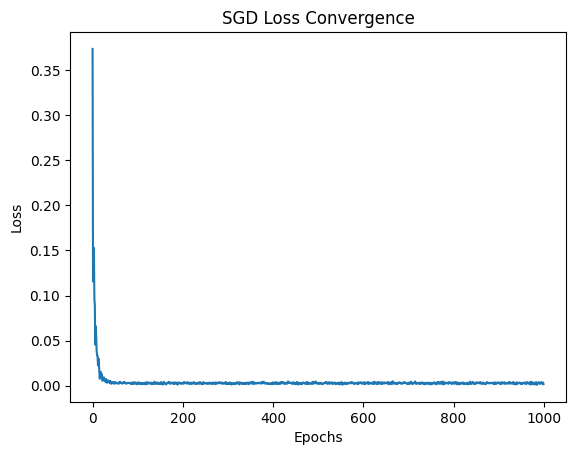

In [18]:
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("SGD Loss Convergence")
plt.show()

# 📌 Predictions on Test Set

In [19]:
y_pred_sgd = X_test.dot(theta_sgd)

# 📌 Compute Mean Squared Error

In [20]:
mse_sgd = np.mean((y_pred_sgd - y_test) ** 2)
print(f"SGD Test Mean Squared Error: {mse_sgd:.4f}")

SGD Test Mean Squared Error: 0.1473


# 📌 Comparison with Normal Equation

In [21]:
theta_normal = np.linalg.inv(X_train.T.dot(X_train)).dot(X_train.T).dot(y_train)
y_pred_normal = X_test.dot(theta_normal)
mse_normal = np.mean((y_pred_normal - y_test) ** 2)

print(f"Normal Equation Test Mean Squared Error: {mse_normal:.4f}")

Normal Equation Test Mean Squared Error: 0.1473


# 📌 Print Final Weights (Theta)

In [22]:

print("\nFinal Model Parameters (Theta) from SGD:")
print(theta_sgd)


Final Model Parameters (Theta) from SGD:
[ 0.47130064 -0.14699921 -0.02053069 -0.02816649 -0.00623298 -0.01382779
  0.01683163  0.02199614 -0.00099387  0.02711254  0.0025002  -0.00090082
  0.03520693 -0.01111297]
